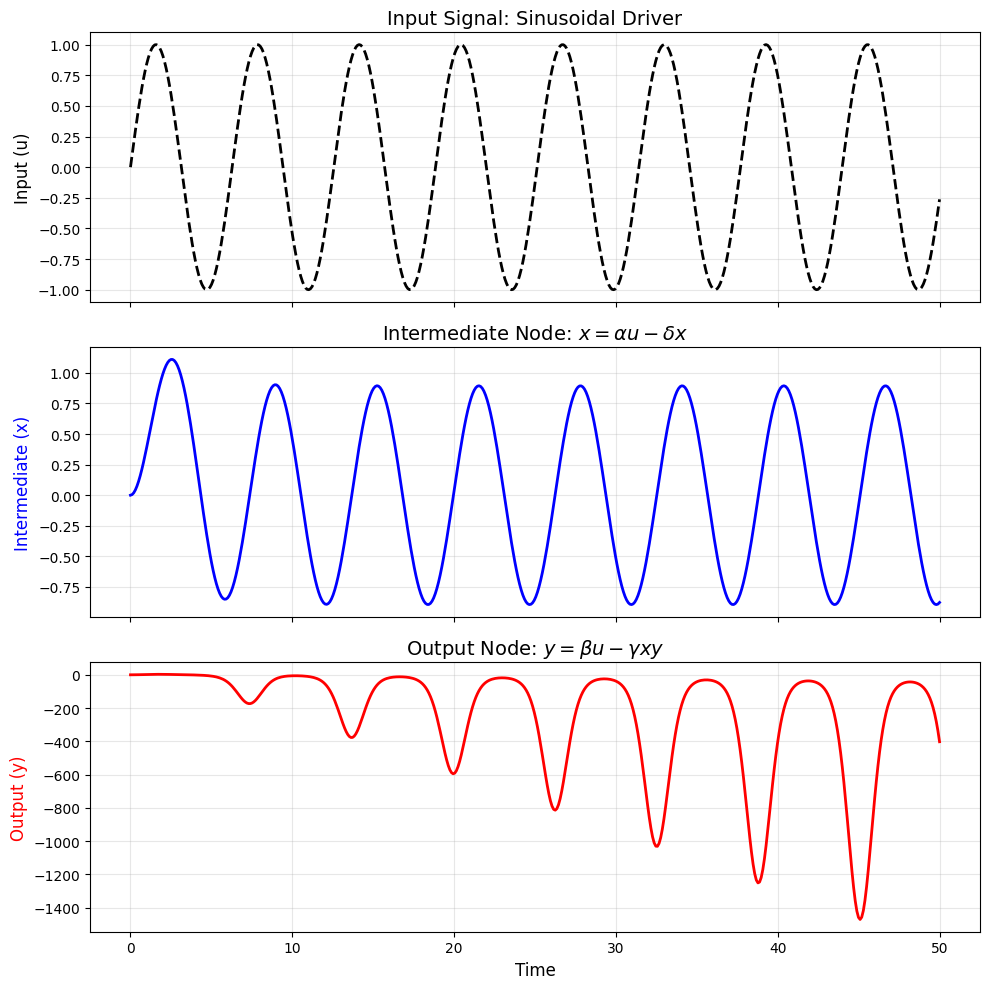

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# 1. Define the Input Signal u(t)
def input_signal(t):
    # Sinusoidal input: Shifted up by 1.0 to keep concentration non-negative
    frequency = 0.5
    amplitude = 1.0
    bias = 1.0
    return amplitude * np.sin(frequency * t) + bias

# 2. Define the Differential Equations
def iffl_model(state, t, alpha, beta, delta, gamma):
    x, y = state
    u = input_signal(t)
    
    # Equation 1: x = alpha*u - delta*x
    dxdt = (alpha * u) - (delta * x)
    
    # Equation 2: y = beta*u - gamma*xy
    dydt = (beta * u) - (gamma * x * y)
    
    return [dxdt, dydt]

# 3. Parameters
# alpha/beta: Production rates
# delta: x decay rate
# gamma: Interaction strength (repression strength)
alpha = 2.0
beta = 5.0
delta = 0.5
gamma = 2.0

# 4. Simulation Settings
t = np.linspace(0, 50, 500)  # Time grid: 0 to 50 seconds
initial_state = [0.0, 0.0]   # Initial concentrations of [x, y]

# 5. Solve the ODE
solution = odeint(iffl_model, initial_state, t, args=(alpha, beta, delta, gamma))
x_sol = solution[:, 0]
y_sol = solution[:, 1]

# Calculate u(t) for plotting purposes
u_sol = [input_signal(ti) for ti in t]

# 6. Plotting
plt.figure(figsize=(10, 6))

# Plot Input u
plt.plot(t, u_sol, 'k--', label='Input u (Sinusoid)', alpha=0.6, linewidth=1.5)

# Plot Intermediate x
plt.plot(t, x_sol, 'b-', label='Intermediate x (Repressor)', linewidth=2)

# Plot Output y
plt.plot(t, y_sol, 'r-', label='Output y', linewidth=2)

plt.title('IFFL Simulation: y = beta*u - gamma*xy')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

<>:29: SyntaxWarning: invalid escape sequence '\o'
<>:29: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_2503/1694009224.py:29: SyntaxWarning: invalid escape sequence '\o'
  ax1.axvline(x=delta, color='r', linestyle='--', label=f'Corner Freq $\omega_c = {delta}$ rad/s')


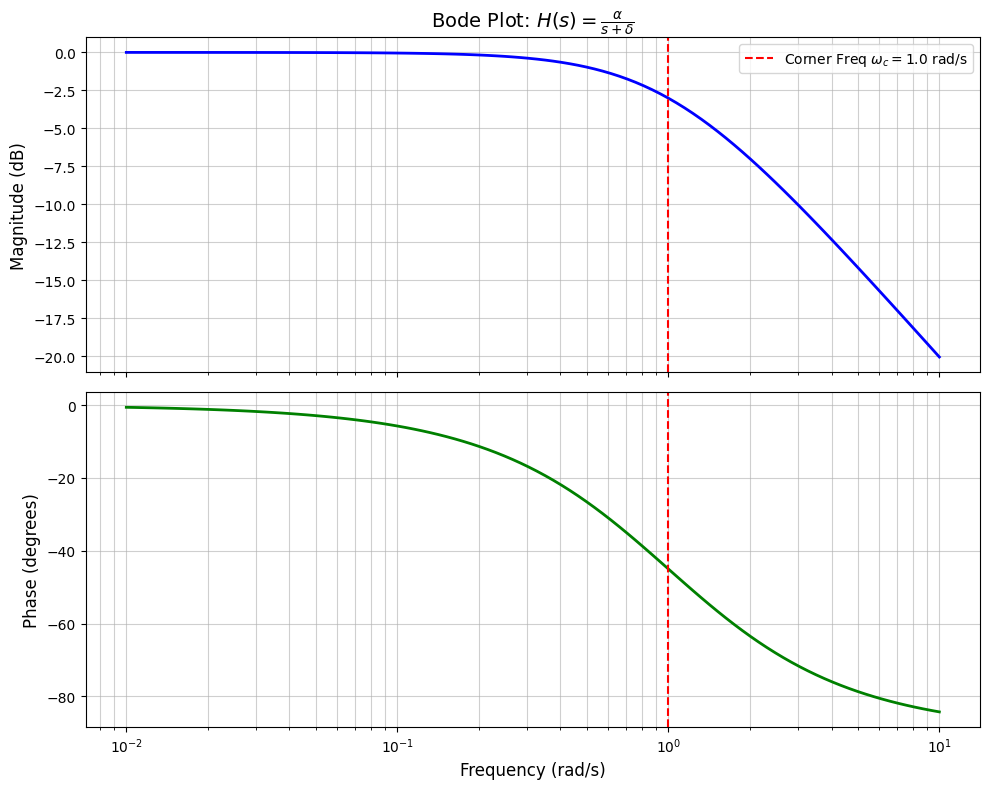

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Define Parameters
alpha = 1.0  # Production rate (Gain)
delta = 1.0  # Decay rate (Bandwidth / Corner Frequency)

# 2. Define the Transfer Function
# H(s) = numerator / denominator
# numerator = [alpha]
# denominator = [1, delta]  -> corresponds to (1*s + delta)
system = signal.TransferFunction([alpha], [1, delta])

# 3. Calculate Bode Plot Data
# w is frequency in rad/s, mag is in dB, phase is in degrees
w, mag, phase = signal.bode(system)

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Magnitude Plot
ax1.semilogx(w, mag, 'b-', linewidth=2)
ax1.set_title(r'Bode Plot: $H(s) = \frac{\alpha}{s + \delta}$', fontsize=14)
ax1.set_ylabel('Magnitude (dB)', fontsize=12)
ax1.grid(True, which="both", ls="-", alpha=0.6)

# Mark the Corner Frequency (delta)
ax1.axvline(x=delta, color='r', linestyle='--', label=f'Corner Freq $\omega_c = {delta}$ rad/s')
ax1.legend()

# Phase Plot
ax2.semilogx(w, phase, 'g-', linewidth=2)
ax2.set_ylabel('Phase (degrees)', fontsize=12)
ax2.set_xlabel('Frequency (rad/s)', fontsize=12)
ax2.grid(True, which="both", ls="-", alpha=0.6)
ax2.axvline(x=delta, color='r', linestyle='--')

plt.tight_layout()
plt.show()

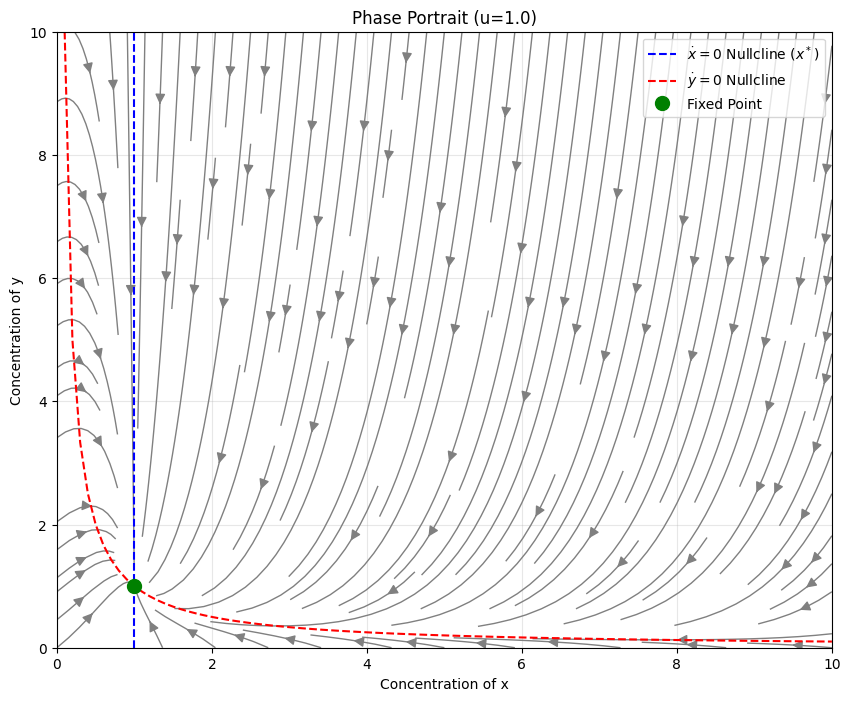

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
alpha = 1.0
beta = 1.0
delta = 1.0
gamma = 1.0
u_const = 1.0  # Constant input

# System definition
def iffl_model_const_u(state, t):
    x, y = state
    dxdt = (alpha * u_const) - (delta * x)
    dydt = (beta * u_const) - (gamma * x * y)
    return [dxdt, dydt]

# Grid for vector field
x_range = np.linspace(0, 10, 20)
y_range = np.linspace(0, 10, 20)
X, Y = np.meshgrid(x_range, y_range)

# Vector field calculation
DX = (alpha * u_const) - (delta * X)
DY = (beta * u_const) - (gamma * X * Y)

# Nullclines
# dx/dt = 0 -> x = alpha*u/delta
nullcline_x = (alpha * u_const) / delta
# dy/dt = 0 -> y = beta*u / (gamma*x)
# Avoid division by zero for plotting
x_null = np.linspace(0.1, 10, 100)
nullcline_y = (beta * u_const) / (gamma * x_null)

# Trajectories
t = np.linspace(0, 10, 1000)
initial_conditions = [
    [0.1, 0.1],
    [0.1, 8.0],
    [8.0, 8.0],
    [8.0, 0.1],
    [4.0, 4.0] # Near equilibrium
]

trajectories = []
for y0 in initial_conditions:
    sol = odeint(iffl_model_const_u, y0, t)
    trajectories.append(sol)

# Plotting
plt.figure(figsize=(10, 8))

# Streamplot for vector field
plt.streamplot(X, Y, DX, DY, color='gray', linewidth=1, density=1.5, arrowsize=1.5)

# Plot Nullclines
plt.axvline(x=nullcline_x, color='b', linestyle='--', label=r'$\dot{x}=0$ Nullcline ($x^*$)')
plt.plot(x_null, nullcline_y, 'r--', label=r'$\dot{y}=0$ Nullcline')

# Plot Trajectories
# for i, sol in enumerate(trajectories):
#     plt.plot(sol[:, 0], sol[:, 1], 'k-', linewidth=2)
#     # Mark start
#     plt.plot(sol[0, 0], sol[0, 1], 'ko')

# Fixed point
fixed_x = (alpha * u_const) / delta
fixed_y = (beta * u_const) / (gamma * fixed_x)
plt.plot(fixed_x, fixed_y, 'go', markersize=10, label='Fixed Point', zorder=5)

plt.title(f'Phase Portrait (u={u_const})')
plt.xlabel('Concentration of x')
plt.ylabel('Concentration of y')
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('phase_portrait.png')

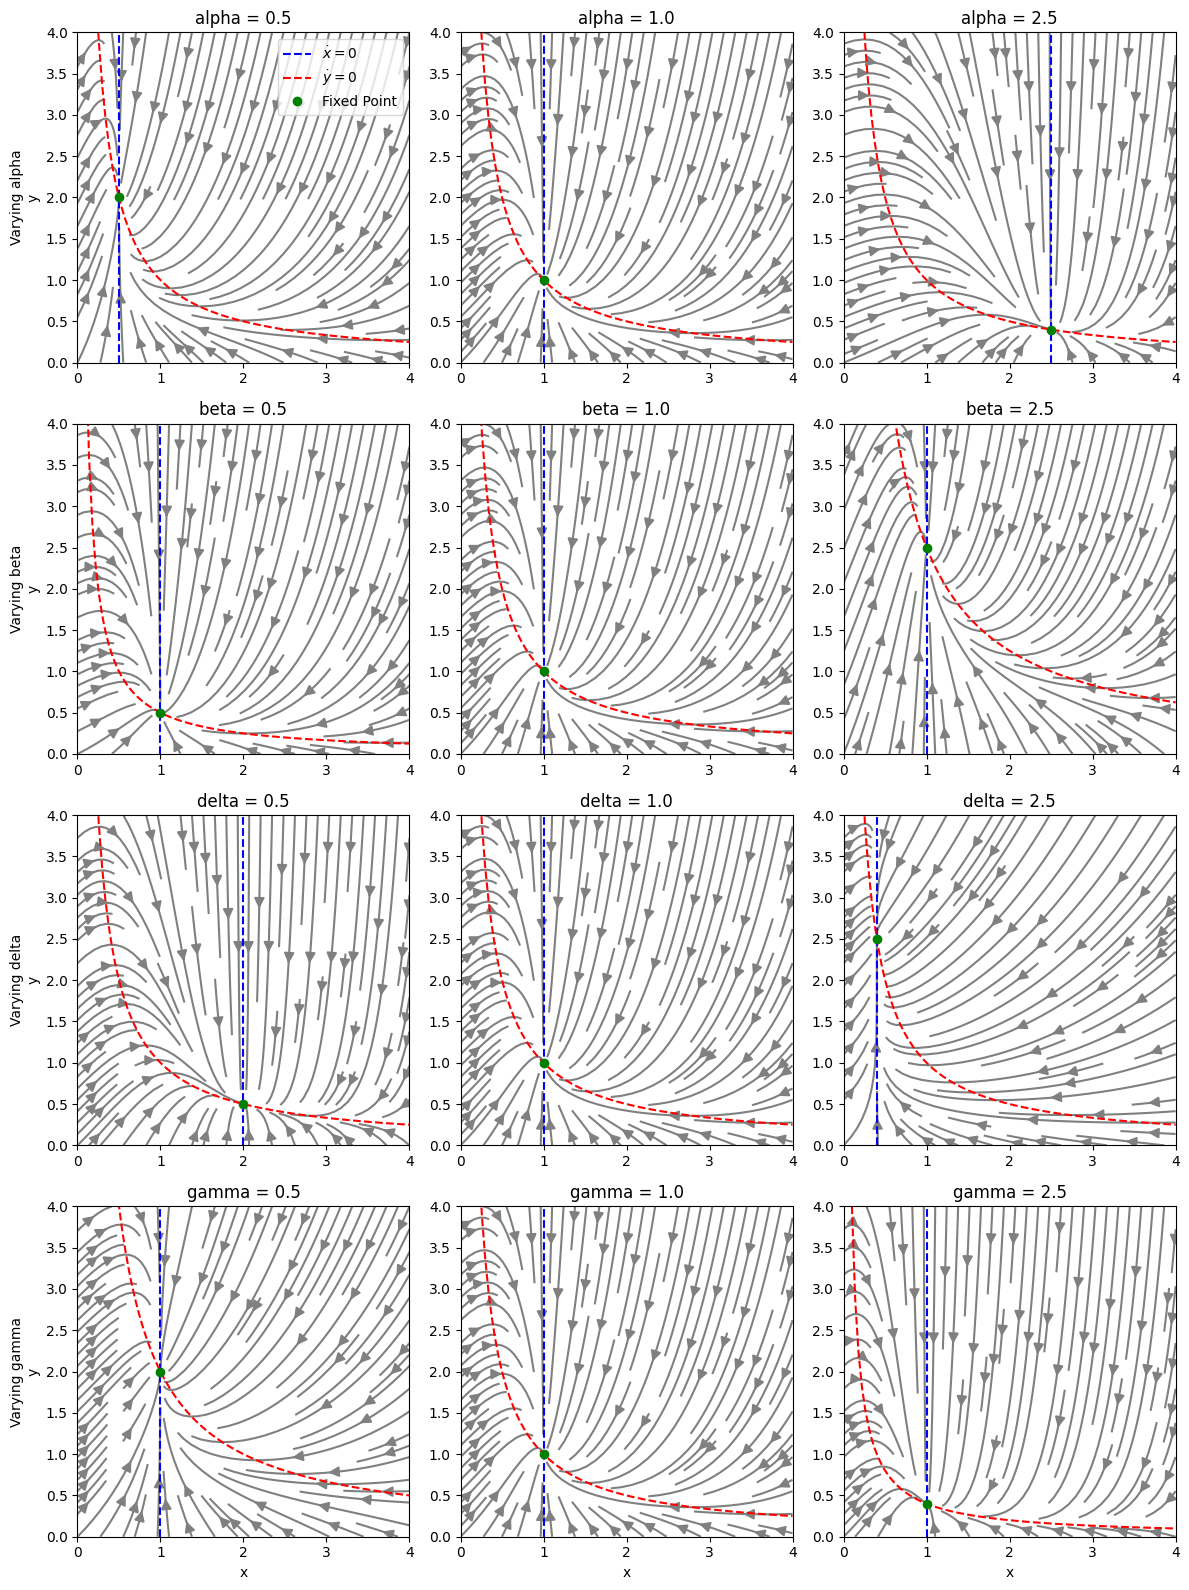

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Base parameters
base_params = {'alpha': 1.0, 'beta': 1.0, 'delta': 1.0, 'gamma': 1.0}
u = 1.0

# Variations
variations = [
    ('alpha', [0.5, 1.0, 2.5]),
    ('beta', [0.5, 1.0, 2.5]),
    ('delta', [0.5, 1.0, 2.5]),
    ('gamma', [0.5, 1.0, 2.5])
]

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for row_idx, (param_name, values) in enumerate(variations):
    for col_idx, val in enumerate(values):
        ax = axes[row_idx, col_idx]
        
        # Copy base params and update the specific one
        params = base_params.copy()
        params[param_name] = val
        
        # Extract for cleaner code
        a = params['alpha']
        b = params['beta']
        d = params['delta']
        g = params['gamma']
        
        # Grid
        x = np.linspace(0, 4, 20)
        y = np.linspace(0, 4, 20)
        X, Y = np.meshgrid(x, y)
        
        # Equations
        # dx/dt = a*u - d*x
        DX = a*u - d*X
        # dy/dt = b*u - g*x*y
        DY = b*u - g*X*Y
        
        # Streamplot
        ax.streamplot(X, Y, DX, DY, color='gray', density=1, arrowsize=1.5)
        
        # Nullclines
        # x-nullcline: x = a*u/d
        x_null = (a*u)/d
        ax.axvline(x_null, color='b', linestyle='--', label=r'$\dot{x}=0$' if (row_idx==0 and col_idx==0) else "")
        
        # y-nullcline: y = b*u / (g*x)
        x_line = np.linspace(0.1, 4, 100)
        y_line = (b*u) / (g*x_line)
        ax.plot(x_line, y_line, 'r--', label=r'$\dot{y}=0$' if (row_idx==0 and col_idx==0) else "")
        
        # Fixed point
        fixed_x = x_null
        fixed_y = (b*u)/(g*fixed_x)
        ax.plot(fixed_x, fixed_y, 'go', label='Fixed Point' if (row_idx==0 and col_idx==0) else "")
        
        ax.set_title(f'{param_name} = {val}')
        ax.set_xlim(0, 4)
        ax.set_ylim(0, 4)
        
        if col_idx == 0:
            ax.set_ylabel(f'Varying {param_name}\ny')
        if row_idx == 3:
            ax.set_xlabel('x')
            
        if row_idx == 0 and col_idx == 0:
            ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('phase_portraits_grid.png')

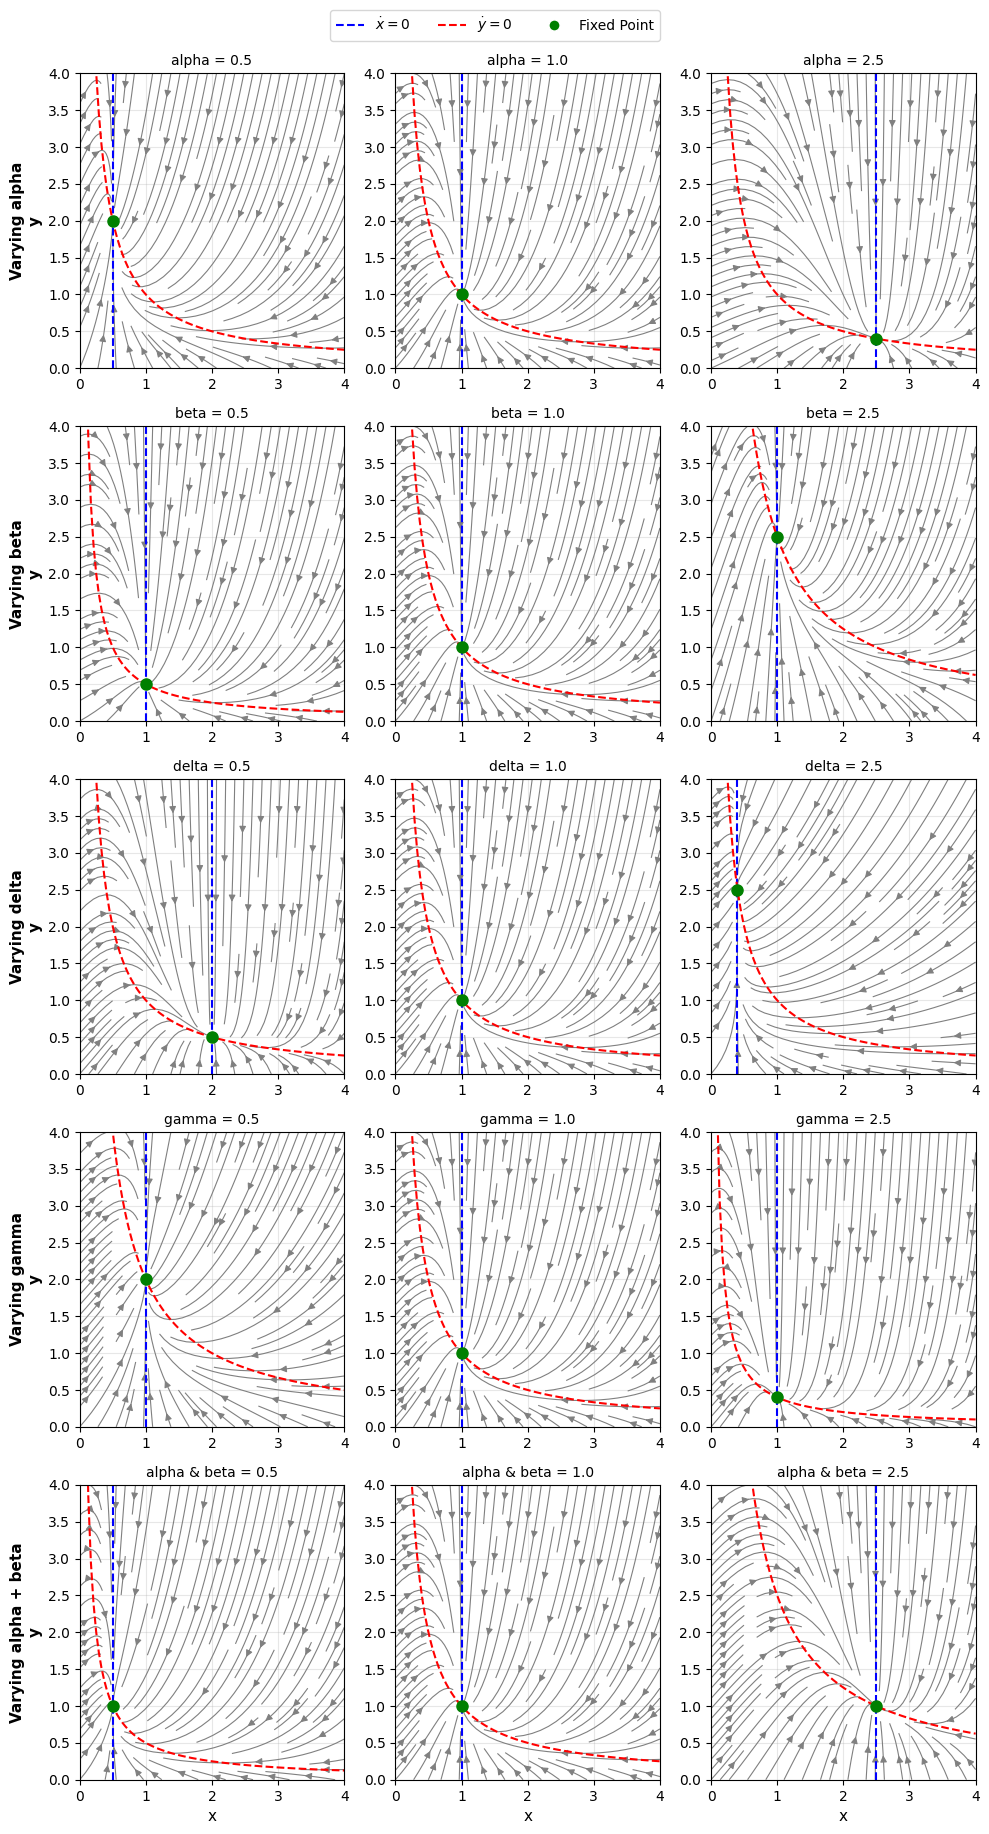

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Base parameters
base_params = {'alpha': 1.0, 'beta': 1.0, 'delta': 1.0, 'gamma': 1.0}
u = 1.0

# 2. Define Variations (Now with 5 rows)
# The last tuple 'alpha_beta' will trigger simultaneous changes
variations = [
    ('alpha', [0.5, 1.0, 2.5]),
    ('beta', [0.5, 1.0, 2.5]),
    ('delta', [0.5, 1.0, 2.5]),
    ('gamma', [0.5, 1.0, 2.5]),
    ('alpha_beta', [0.5, 1.0, 2.5]) # New Row
]

# 3. Setup Plot Grid (5 rows, 3 columns)
fig, axes = plt.subplots(5, 3, figsize=(10, 18))

# 4. Simulation Loop
for row_idx, (param_name, values) in enumerate(variations):
    for col_idx, val in enumerate(values):
        ax = axes[row_idx, col_idx]
        
        # Reset to base parameters
        params = base_params.copy()
        
        # Apply the variation
        if param_name == 'alpha_beta':
            # Multiply both base alpha and beta by the value
            params['alpha'] = base_params['alpha'] * val
            params['beta'] = base_params['beta'] * val
            title_str = f'alpha & beta = {val}'
        else:
            # Set the specific parameter
            params[param_name] = val
            title_str = f'{param_name} = {val}'
        
        # Extract for cleaner equations
        a = params['alpha']
        b = params['beta']
        d = params['delta']
        g = params['gamma']
        
        # Create Grid
        x_range = np.linspace(0, 4, 20)
        y_range = np.linspace(0, 4, 20)
        X, Y = np.meshgrid(x_range, y_range)
        
        # Calculate Vector Field
        # dx/dt = a*u - d*x
        DX = (a * u) - (d * X)
        # dy/dt = b*u - g*x*y
        DY = (b * u) - (g * X * Y)
        
        # Streamplot
        ax.streamplot(X, Y, DX, DY, color='gray', density=1, arrowsize=1.0, linewidth=0.8)
        
        # Plot Nullclines
        # x-nullcline (dx/dt = 0): x = a*u/d
        x_null = (a * u) / d
        ax.axvline(x_null, color='b', linestyle='--', label=r'$\dot{x}=0$')
        
        # y-nullcline (dy/dt = 0): y = b*u / (g*x)
        # Avoid division by zero
        x_line = np.linspace(0.05, 4, 100)
        y_line = (b * u) / (g * x_line)
        ax.plot(x_line, y_line, 'r--', label=r'$\dot{y}=0$')
        
        # Plot Fixed Point
        fixed_y = (b * u) / (g * x_null)
        ax.plot(x_null, fixed_y, 'go', markersize=8, zorder=5)
        
        # Formatting
        ax.set_xlim(0, 4)
        ax.set_ylim(0, 4)
        ax.set_title(title_str, fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Label rows and columns
        if col_idx == 0:
            row_label = param_name.replace('_', ' + ')
            ax.set_ylabel(f'Varying {row_label}\ny', fontsize=11, fontweight='bold')
        if row_idx == 4: # Last row
            ax.set_xlabel('x', fontsize=11)

# Add a single legend to the top of the figure
handles, labels = axes[0, 0].get_legend_handles_labels()
# Add a dummy handle for the Fixed Point since we plotted it directly
from matplotlib.lines import Line2D
fixed_point_proxy = Line2D([0], [0], color='w', marker='o', markerfacecolor='g', markersize=8, label='Fixed Point')
handles.append(fixed_point_proxy)
labels.append('Fixed Point')

fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

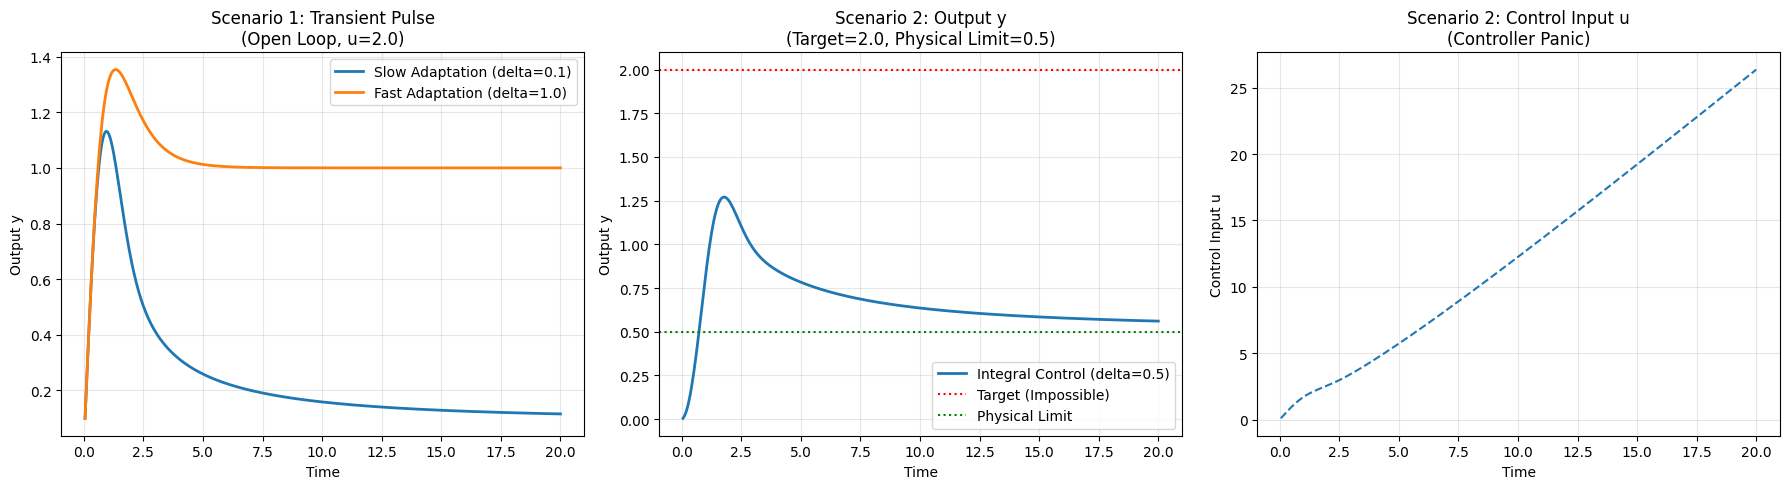

In [15]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Re-implementing your class structure for a standalone run
class IFFL2Vars:
    def __init__(self, fixed_params=None):
        if fixed_params is None:
            # Default: alpha=1.0, delta=0.1, beta=1.0, gamma=1.0
            self.fixed_params = torch.tensor([1.0, 0.1, 1.0, 1.0])
        else:
            self.fixed_params = fixed_params

    def forward(self, t, x, control=None):
        alpha, delta, beta, gamma = self.fixed_params
        
        # Default control u=1.0 if not provided
        u = control[0] if (control is not None and len(control) > 0) else torch.tensor(1.0)
        
        # Input signal is constant 1.0 for this test
        Input = torch.tensor(1.0) 
        controlled_input = u * Input
        
        x_state, y_state = x[0], x[1]
        
        # dx/dt = alpha * u - delta * x
        dx_dt = alpha * controlled_input - delta * x_state
        
        # dy/dt = beta * u - gamma * x * y
        dy_dt = beta * controlled_input - gamma * x_state * y_state
        
        return torch.stack([dx_dt, dy_dt])

def run_simulation(delta_val, label, ax_y, ax_u=None, target=None):
    # Setup params: alpha=1, delta=VARIES, beta=1, gamma=1
    # Steady State y_ss = (beta*delta)/(alpha*gamma) = (1*delta)/(1*1) = delta
    params = torch.tensor([1.0, delta_val, 1.0, 1.0])
    model = IFFL2Vars(fixed_params=params)
    
    dt = 0.05
    steps = 400
    t = 0.0
    
    # Initial state [x=0, y=0]
    x = torch.tensor([0.0, 0.0])
    
    # Storage for plotting
    history_t = []
    history_y = []
    history_u = []
    
    # Integral error for controller
    integral_error = 0.0
    
    for i in range(steps):
        # --- CONTROL LOGIC ---
        if target is None:
            # Open Loop: Constant control input
            u = torch.tensor([2.0]) # Step input to 2.0
        else:
            # Closed Loop: Integral Controller
            # Trying to force y to 'target'
            current_y = x[1].item()
            error = target - current_y
            integral_error += error * dt
            
            # Simple Integral Controller: u = Ki * integral_error
            # We clip it to be positive to make physical sense
            u_val = max(0.0, 1.0 * integral_error) 
            u = torch.tensor([u_val])

        # --- DYNAMICS ---
        dx = model.forward(t, x, control=u)
        x = x + dx * dt
        t += dt
        
        history_t.append(t)
        history_y.append(x[1].item())
        history_u.append(u[0].item())

    # Plotting
    ax_y.plot(history_t, history_y, label=f'{label} (delta={delta_val})', linewidth=2)
    if ax_u:
        ax_u.plot(history_t, history_u, label=f'{label} Control', linestyle='--')

# --- PLOTTING SETUP ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# SCENARIO 1: The "Perfect Adaptation" Pulse (Open Loop)
# We test different delta values to show how 'x' speed affects the 'y' spike.
ax1.set_title("Scenario 1: Transient Pulse\n(Open Loop, u=2.0)")
run_simulation(delta_val=0.1, label="Slow Adaptation", ax_y=ax1)
run_simulation(delta_val=1.0, label="Fast Adaptation", ax_y=ax1)
ax1.set_xlabel("Time")
ax1.set_ylabel("Output y")
ax1.legend()
ax1.grid(True, alpha=0.3)

# SCENARIO 2: The Controller Trap (Closed Loop)
# We try to force y to 2.0. 
# BUT: With alpha=1, gamma=1, beta=1, the physical steady state is strictly 'delta'.
# If we set delta=0.5, the system physically can ONLY settle at y=0.5.
# The controller will try to force it to 2.0.
DELTA_FIXED = 0.5
TARGET_IMPOSSIBLE = 2.0

run_simulation(delta_val=DELTA_FIXED, label="Integral Control", 
               ax_y=ax2, ax_u=ax3, target=TARGET_IMPOSSIBLE)

ax2.set_title(f"Scenario 2: Output y\n(Target={TARGET_IMPOSSIBLE}, Physical Limit={DELTA_FIXED})")
ax2.axhline(y=TARGET_IMPOSSIBLE, color='r', linestyle=':', label="Target (Impossible)")
ax2.axhline(y=DELTA_FIXED, color='g', linestyle=':', label="Physical Limit")
ax2.set_xlabel("Time")
ax2.set_ylabel("Output y")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.set_title("Scenario 2: Control Input u\n(Controller Panic)")
ax3.set_xlabel("Time")
ax3.set_ylabel("Control Input u")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

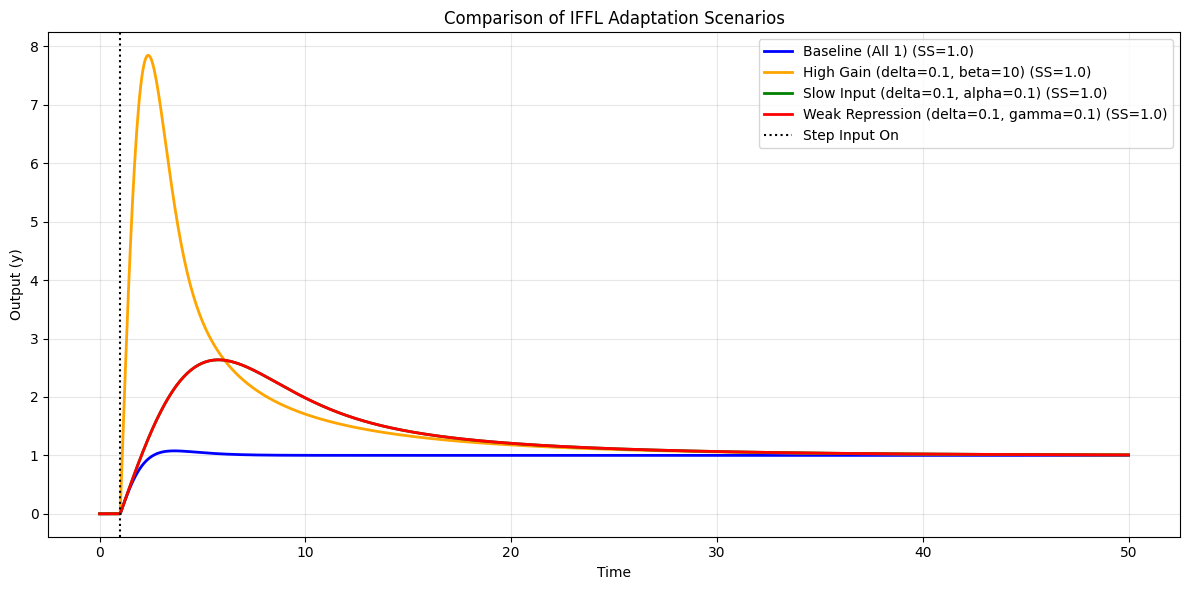

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Define the ODE system
def iffl_dynamics(state, t, alpha, delta, beta, gamma, u):
    x, y = state
    input_signal = 1.0 if t > 1.0 else 0.0 # Step input at t=1
    
    # Equations
    # dx/dt = alpha * (u * Input) - delta * x
    dxdt = alpha * (u * input_signal) - delta * x
    
    # dy/dt = beta * (u * Input) - gamma * x * y
    dydt = beta * (u * input_signal) - gamma * x * y
    
    return [dxdt, dydt]

# Simulation parameters
t = np.linspace(0, 50, 1000)
u_control = 1.0 # Constant control multiplier

# Define the 4 scenarios
scenarios = [
    {
        "name": "Baseline (All 1)",
        "params": {"alpha": 1.0, "delta": 1.0, "beta": 1.0, "gamma": 1.0},
        "style": "b-"
    },
    {
        "name": "High Gain (delta=0.1, beta=10)",
        "params": {"alpha": 1.0, "delta": 0.1, "beta": 10.0, "gamma": 1.0},
        "style": "orange"
    },
    {
        "name": "Slow Input (delta=0.1, alpha=0.1)",
        "params": {"alpha": 0.1, "delta": 0.1, "beta": 1.0, "gamma": 1.0},
        "style": "g-"
    },
    {
        "name": "Weak Repression (delta=0.1, gamma=0.1)",
        "params": {"alpha": 1.0, "delta": 0.1, "beta": 1.0, "gamma": 0.1},
        "style": "r-"
    }
]

# Run simulations
plt.figure(figsize=(12, 6))

for sc in scenarios:
    p = sc["params"]
    # Calculate theoretical steady state for y: y_ss = (beta * delta) / (alpha * gamma)
    y_ss_theory = (p["beta"] * p["delta"]) / (p["alpha"] * p["gamma"])
    
    solution = odeint(iffl_dynamics, [0.0, 0.0], t, 
                      args=(p["alpha"], p["delta"], p["beta"], p["gamma"], u_control))
    
    y_traj = solution[:, 1]
    
    plt.plot(t, y_traj, sc["style"], label=f"{sc['name']} (SS={y_ss_theory:.1f})", linewidth=2)

plt.title("Comparison of IFFL Adaptation Scenarios")
plt.xlabel("Time")
plt.ylabel("Output (y)")
plt.axvline(x=1.0, color='k', linestyle=':', label="Step Input On")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

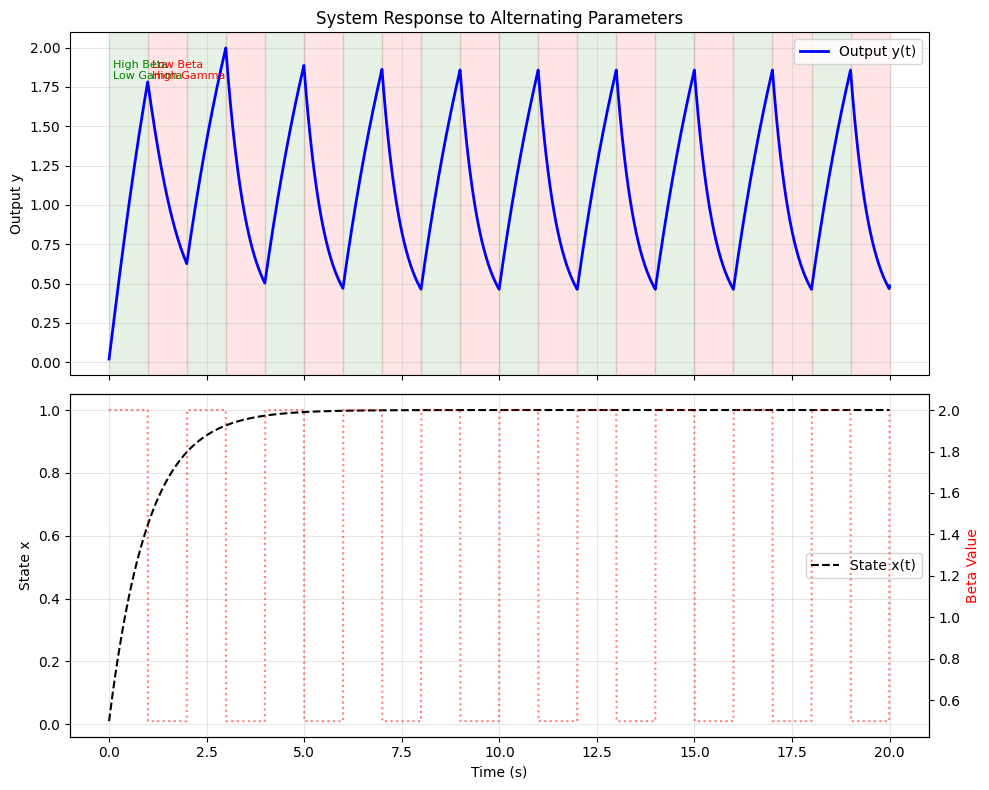

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_switching_system():
    # Simulation settings
    duration = 20.0
    dt = 0.01
    steps = int(duration / dt)
    time = np.linspace(0, duration, steps)

    # Fixed parameters
    alpha = 1.0
    delta = 1.0
    u_control = 1.0
    input_signal = 1.0

    # Initial state [x, y]
    x = 0.0
    y = 0.0

    # Arrays to store history
    t_hist = []
    x_hist = []
    y_hist = []
    beta_hist = []  # To visualize the switching

    for t in time:
        # --- Determine parameters based on time ---
        # Switch every 1.0 second
        # If integer part of time is even: Phase A. If odd: Phase B.
        if int(t) % 2 == 0:
            beta = 2.0
            gamma = 0.5
        else:
            beta = 0.5
            gamma = 2.0

        # --- Compute Derivatives ---
        # dx/dt = alpha * u - delta * x
        dxdt = alpha * (u_control * input_signal) - delta * x

        # dy/dt = beta * u - gamma * x * y
        dydt = beta * (u_control * input_signal) - gamma * x * y

        # --- Update State (Euler Integration) ---
        x += dxdt * dt
        y += dydt * dt

        # Store history
        t_hist.append(t)
        x_hist.append(x)
        y_hist.append(y)
        beta_hist.append(beta)

    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Plot 1: The Output y(t)
    ax1.plot(t_hist, y_hist, 'b-', linewidth=2, label='Output y(t)')
    ax1.set_ylabel('Output y')
    ax1.set_title('System Response to Alternating Parameters')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    # Add background shading to show phases
    for t in range(0, int(duration)):
        if t % 2 == 0:
            # Phase A region
            ax1.axvspan(t, t+1, color='green', alpha=0.1)
            if t == 0: ax1.text(t+0.1, max(y_hist)*0.9, "High Beta\nLow Gamma", color='green', fontsize=8)
        else:
            # Phase B region
            ax1.axvspan(t, t+1, color='red', alpha=0.1)
            if t == 1: ax1.text(t+0.1, max(y_hist)*0.9, "Low Beta\nHigh Gamma", color='red', fontsize=8)

    # Plot 2: The State x(t) and Parameter Beta
    ax2.plot(t_hist, x_hist, 'k--', label='State x(t)')
    ax2.set_ylabel('State x')
    
    # Create a twin axis to show the switching Beta
    ax2_beta = ax2.twinx()
    ax2_beta.plot(t_hist, beta_hist, 'r:', label='Parameter Beta', alpha=0.5)
    ax2_beta.set_ylabel('Beta Value', color='r')
    
    ax2.set_xlabel('Time (s)')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='center right')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    simulate_switching_system()

Starting integration with dopri5...


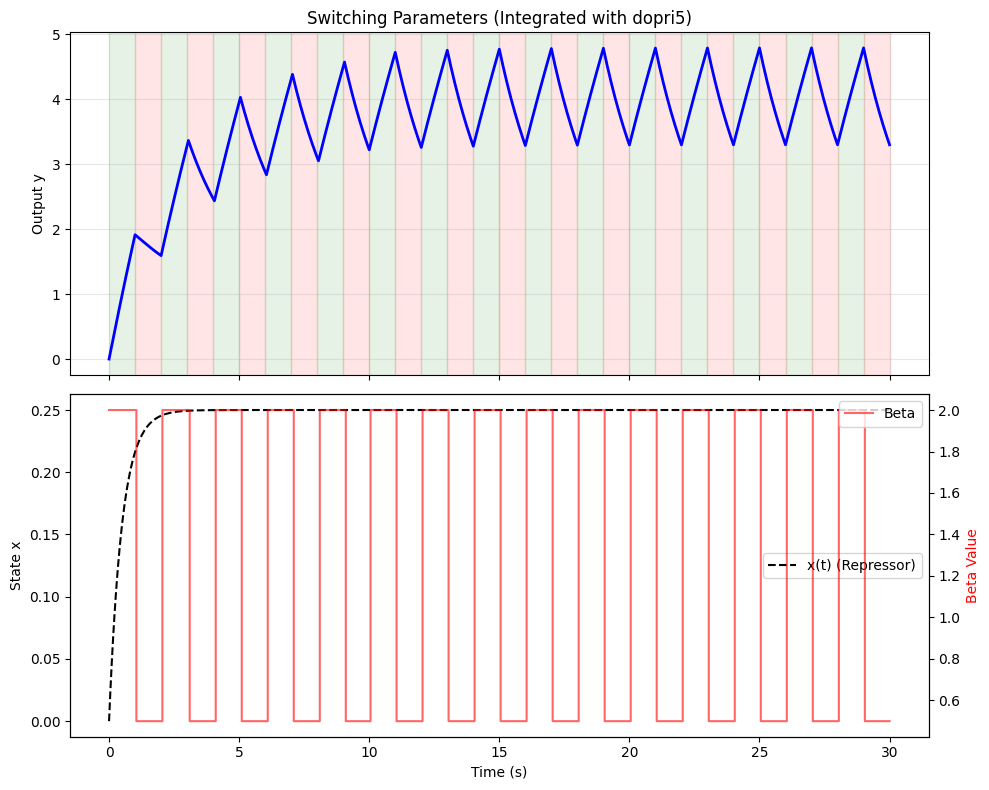

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import ode

class IFFL2Vars:
    """Class to hold system parameters and equations."""
    def __init__(self):
        # Fixed base parameters
        self.alpha = 0.5
        self.delta = 2.0
        self.control = 1.0
        self.input_signal = 1.0
        
        # Current variable parameters (will be updated)
        self.beta = 2.0
        self.gamma = 0.5

    def derivatives(self, t, state):
        x, y = state
        
        # dx/dt = alpha * (control * Input) - delta * x
        dxdt = self.alpha * (self.control * self.input_signal) - self.delta * x
        
        # dy/dt = beta * (control * Input) - gamma * x * y
        dydt = self.beta * (self.control * self.input_signal) - self.gamma * x * y
        
        return [dxdt, dydt]

def run_dopri5_simulation():
    # Simulation Setup
    total_time = 30
    switch_interval = 1.0
    
    # Initialize System
    system = IFFL2Vars()
    
    # Setup Integrator
    # 'dopri5' is an explicit Runge-Kutta method of order (4)5
    r = ode(system.derivatives).set_integrator('dopri5', nsteps=1000)
    
    # Initial State [x=0, y=0]
    y0 = [0.0, 0.0]
    r.set_initial_value(y0, 0.0)
    
    # Storage
    t_values = [0.0]
    x_values = [0.0]
    y_values = [0.0]
    beta_values = [system.beta]
    
    print("Starting integration with dopri5...")
    
    # We loop through each 1-second interval separately
    # This handles the discontinuity cleanly.
    current_interval_end = switch_interval
    
    while r.successful() and r.t < total_time:
        
        # 1. Update Parameters based on current time
        # Even seconds (0-1, 2-3): Phase A (High Beta)
        # Odd seconds (1-2, 3-4): Phase B (High Gamma)
        if int(r.t) % 2 == 0:
            system.beta = 2.0
            system.gamma = 0.5
            phase = "A"
        else:
            system.beta = 0.5
            system.gamma = 2.0
            phase = "B"
            
        # 2. Integrate up to the next switch point
        # We step carefully to capture resolution for plotting
        while r.t < current_interval_end:
            r.integrate(r.t + 0.05) # Step forward by 0.05s
            
            t_values.append(r.t)
            x_values.append(r.y[0])
            y_values.append(r.y[1])
            beta_values.append(system.beta)
        
        # Move target to next second
        current_interval_end += switch_interval

    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Plot Y (Output)
    ax1.plot(t_values, y_values, 'b-', linewidth=2, label='y(t)')
    ax1.set_ylabel('Output y')
    ax1.set_title('Switching Parameters (Integrated with dopri5)')
    ax1.grid(True, alpha=0.3)
    
    # Shade regions
    for t in range(0, total_time):
        color = 'green' if t % 2 == 0 else 'red'
        alpha = 0.1
        ax1.axvspan(t, t+1, color=color, alpha=alpha)

    # Plot X and Beta
    ax2.plot(t_values, x_values, 'k--', label='x(t) (Repressor)')
    ax2.set_ylabel('State x')
    ax2.set_xlabel('Time (s)')
    
    ax2_twin = ax2.twinx()
    ax2_twin.step(t_values, beta_values, 'r-', where='post', label='Beta', alpha=0.6)
    ax2_twin.set_ylabel('Beta Value', color='r')
    
    ax2.legend(loc='center right')
    ax2_twin.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_dopri5_simulation()